installing dependencies

In [12]:
%pip install codecarbon pytesseract pdf2image pandas matplotlib seaborn openai python-dotenv tqdm transformers


Note: you may need to restart the kernel to use updated packages.


importing librarires and verifying file locations

In [13]:
import sys, os, glob, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm import tqdm
from dotenv import load_dotenv

from codecarbon import EmissionsTracker
from openai import OpenAI
from transformers import AutoTokenizer

load_dotenv()



True



We randomly sample 5 PDF reports (fixed seed)
to ensure fairness and reproducibility across all runs.


In [14]:
NOTEBOOK_PATH = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_PATH.parent

sys.path.insert(0, str(PROJECT_ROOT))

from model.model_implement import run_pipeline_for_experiment
from src.ocr_engine import extract_text_from_pdf


REPORTS_DIR = os.path.join(PROJECT_ROOT, "report", "reports")
ALL_PDFS = glob.glob(os.path.join(REPORTS_DIR, "**", "*.pdf"), recursive=True)

assert len(ALL_PDFS) >= 5, "Need at least 5 PDFs"

RANDOM_SEED = 42
SAMPLE_SIZE = 5

random.seed(RANDOM_SEED)
SAMPLED_PDFS = random.sample(ALL_PDFS, SAMPLE_SIZE)

print("📄 Sampled PDFs:")
for p in SAMPLED_PDFS:
    print("-", os.path.basename(p))




📄 Sampled PDFs:
- Spanish_LIVER_abnormal_4.pdf
- English_BLOOD_normal_1.pdf
- Bengali_BLOOD_normal_3.pdf
- French_LIVER_normal_3.pdf
- French_KIDNEY_normal_3.pdf


## Tokenization

Tokenizer-based token counting is used **only for local Mistral runs**.
Cloud token counts are taken from API usage reports.


In [15]:
local_tokenizer = AutoTokenizer.from_pretrained(
    "mistralai/Mistral-7B-Instruct-v0.2",
    use_fast=True
)


## OCR Energy Measurement

OCR energy is measured **once** on sampled PDFs
and averaged. This value is added to cloud runs
to ensure fair OCR + LLM comparison.


In [16]:
def measure_ocr_energy(pdf_list):
    energies = []

    for pdf in tqdm(pdf_list, desc="OCR profiling"):
        tracker = EmissionsTracker(
            project_name="ocr_only",
            tracking_mode="process",
            measure_power_secs=1,
            save_to_file=False,
            log_level="error"
        )

        tracker.start()
        _ = extract_text_from_pdf(pdf)
        tracker.stop()

        energies.append(tracker.final_emissions_data.energy_consumed)
        time.sleep(0.5)

    avg_kwh = np.mean(energies)
    avg_j = avg_kwh * 3.6e6

    print(f"✅ Avg OCR Energy: {avg_j:.2f} J/document")
    return avg_kwh, avg_j

AVG_OCR_KWH, AVG_OCR_J = measure_ocr_energy(SAMPLED_PDFS)


OCR profiling:   0%|          | 0/5 [00:00<?, ?it/s]

Scanning 1 pages using languages: [eng+fra+deu+spa+hin+mar+ben]...


OCR profiling:  20%|██        | 1/5 [00:07<00:29,  7.39s/it]

Scanning 1 pages using languages: [eng+fra+deu+spa+hin+mar+ben]...


OCR profiling:  40%|████      | 2/5 [00:13<00:20,  6.75s/it]

...

Scanning 1 pages using languages: [eng+fra+deu+spa+hin+mar+ben]...


OCR profiling:  80%|████████  | 4/5 [00:27<00:06,  6.78s/it]

Scanning 1 pages using languages: [eng+fra+deu+spa+hin+mar+ben]...


OCR profiling: 100%|██████████| 5/5 [00:33<00:00,  6.79s/it]

✅ Avg OCR Energy: 210.00 J/document


## Local Pipeline (OCR + Mistral)

Energy is measured end-to-end using CodeCarbon.


In [17]:
def run_local(pdf_list):
    rows = []

    for pdf in tqdm(pdf_list, desc="Local OCR + Mistral"):
        tracker = EmissionsTracker(
            project_name="local_pipeline",
            tracking_mode="process",
            gpu_ids=[0],
            measure_power_secs=1,
            save_to_file=False,
            log_level="error"
        )

        tracker.start()
        start = time.time()

        
        output = run_pipeline_for_experiment(
            pdf_path=pdf,
            language="English",
            model="mistral"
        )

        duration = time.time() - start
        emissions = tracker.stop()
        energy_kwh = tracker.final_emissions_data.energy_consumed

        
        total_tokens = (output.get("input_length", 0) + output.get("output_length", 0)) // 4

        rows.append({
            "File": os.path.basename(pdf),
            "Mode": "Local (OCR + Mistral)",
            "Provider": "Local",
            "Energy (Joules)": energy_kwh * 3.6e6,
            "Emissions (kgCO2)": emissions,
            "Duration (s)": duration,
            "Tokens": total_tokens,
            "Cost (USD)": 0.0
        })

        time.sleep(0.5)

    return pd.DataFrame(rows)


## Cloud Pipeline

OCR energy (measured locally) is added to
estimated cloud LLM energy using token-based estimates.


In [18]:
# Pricing Table (USD per 1M tokens) - Updated Jan 2026
PRICING_TABLE = {
    "openai/gpt-4o-mini":                {"input": 0.15, "output": 0.60},
    "deepseek/deepseek-chat":            {"input": 0.14, "output": 0.28},
    
    
    "x-ai/grok-2-1212":                  {"input": 2.00, "output": 10.00},

    "meta-llama/llama-3.3-70b-instruct": {"input": 0.12, "output": 0.30},
    
    
    "perplexity/sonar":                  {"input": 1.00, "output": 1.00},
}

def run_cloud(pdf_list, models):
    # Constants inside function
    EST_CLOUD_KWH_PER_1K_TOKENS = 0.004
    GLOBAL_CARBON_INTENSITY = 0.475

    client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=os.getenv("OPENROUTER_API_KEY")
    )

    rows = []

    for model in models:
        # Get pricing
        price_in = PRICING_TABLE.get(model, {}).get("input", 0.0)
        price_out = PRICING_TABLE.get(model, {}).get("output", 0.0)

        print(f"\n☁️ Testing Model: {model}")

        for pdf in tqdm(pdf_list, desc="Processing"):
            try:
                # 1. OCR Extraction
                raw_text = extract_text_from_pdf(pdf)
                if not raw_text: continue
                input_text = raw_text[:6000]

                # 2. API Call
                start = time.time()
                resp = client.chat.completions.create(
                    model=model,
                    messages=[
                        {"role": "system", "content": "Medical Assistant"},
                        {"role": "user", "content": input_text}
                    ]
                )
                duration = time.time() - start
                usage = resp.usage
                
                # 3. Metrics
                tokens = usage.total_tokens
                cost = (usage.prompt_tokens / 1e6 * price_in) + \
                       (usage.completion_tokens / 1e6 * price_out)

                llm_kwh = (tokens / 1000) * EST_CLOUD_KWH_PER_1K_TOKENS
                
                # Use Global AVG_OCR_J from previous cell
                total_energy_j = (llm_kwh * 3.6e6) + AVG_OCR_J
                total_emissions = (llm_kwh + AVG_OCR_KWH) * GLOBAL_CARBON_INTENSITY

                rows.append({
                    "File": os.path.basename(pdf),
                    "Mode": model.split("/")[-1],
                    "Provider": "Cloud",
                    "Energy (Joules)": total_energy_j,
                    "Emissions (kgCO2)": total_emissions,
                    "Duration (s)": duration,
                    "Tokens": tokens,
                    "Cost (USD)": cost
                })
            
            except Exception as e:
                print(f"  ⚠️ Error: {str(e)[:100]}")
                time.sleep(1)

            time.sleep(1)

    return pd.DataFrame(rows)

## Execute Experiment & Save Results


In [19]:
PAID_CLOUD_MODELS = [
    "openai/gpt-4o-mini",
    "deepseek/deepseek-chat",
    "x-ai/grok-2-1212",                  
    "meta-llama/llama-3.3-70b-instruct", 
    "perplexity/sonar"                   
]

# 1. Run Cloud
print("🚀 Starting Paid Cloud Benchmarks...")
df_cloud = run_cloud(SAMPLED_PDFS, PAID_CLOUD_MODELS)

# 2. Run Local (if needed)
df_local = run_local(SAMPLED_PDFS)

# 3. Combine & Save
if 'df_local' in locals() and not df_local.empty:
    df_all = pd.concat([df_local, df_cloud], ignore_index=True)
else:
    df_all = df_cloud

if not df_all.empty:
    df_all.to_csv("energy_benchmark_sampled.csv", index=False)
    print("\n✅ Success! Saved to 'energy_benchmark_sampled.csv'")
    print(df_all.groupby("Mode")[["Energy (Joules)", "Cost (USD)"]].mean())
else:
    print("❌ No data collected. Check API credits.")

🚀 Starting Paid Cloud Benchmarks...

☁️ Testing Model: openai/gpt-4o-mini


Processing:   0%|          | 0/5 [00:00<?, ?it/s]

Scanning 1 pages using languages: [eng+fra+deu+spa+hin+mar+ben]...


Processing:  20%|██        | 1/5 [00:16<01:07, 16.90s/it]

Scanning 1 pages using languages: [eng+fra+deu+spa+hin+mar+ben]...


...

Scanning 1 pages using languages: [eng+fra+deu+spa+hin+mar+ben]...


Local OCR + Mistral:  80%|████████  | 4/5 [15:05<03:47, 227.89s/it]

Scanning 1 pages using languages: [eng+fra+deu+spa+hin+mar+ben]...


Local OCR + Mistral: 100%|██████████| 5/5 [18:21<00:00, 220.35s/it]


✅ Success! Saved to 'energy_benchmark_sampled.csv'
                        Energy (Joules)  Cost (USD)
Mode                                               
Local (OCR + Mistral)      17029.327240    0.000000
deepseek-chat              12000.720847    0.000189
gpt-4o-mini                12092.880847    0.000366
llama-3.3-70b-instruct     18233.040847    0.000314


visualisation

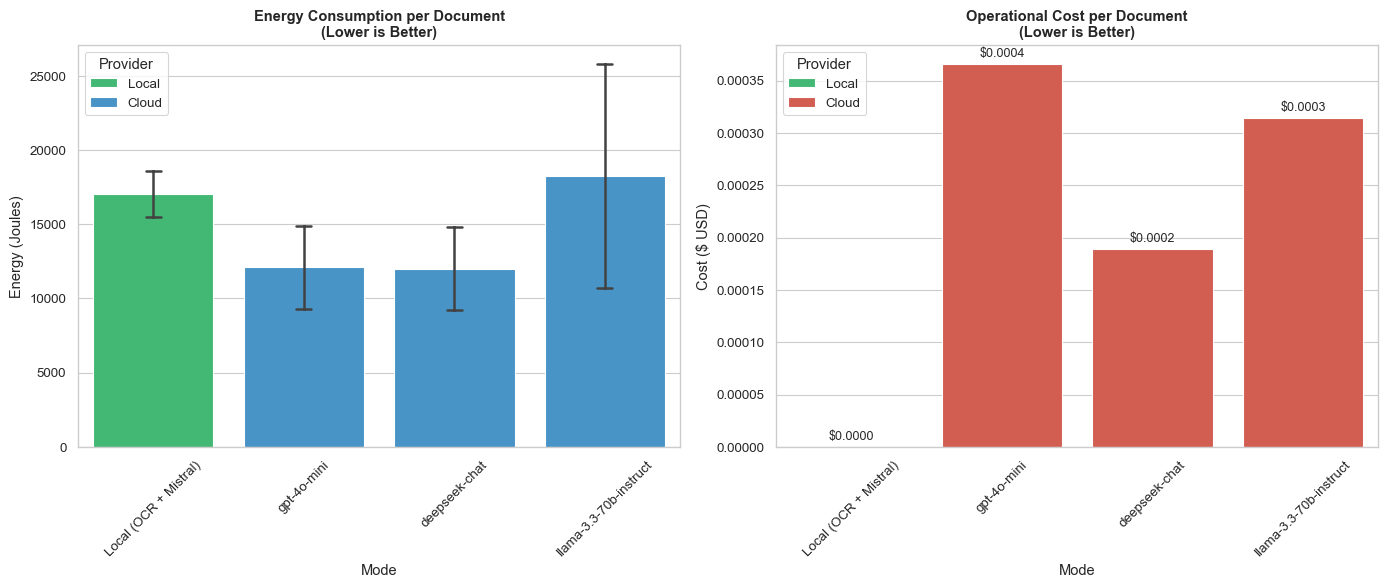

📊 Graphs saved to: c:\Users\sujal\light-weight-ocr-llm-using-mistral-and-paddle-ocr\experiments\benchmark_comparison.png


In [21]:
# %%
# ---------------------------------------------------------
# VISUALIZATION DASHBOARD
# ---------------------------------------------------------
# Set style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# Create a figure with 2 subplots (Energy vs Cost)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- PLOT 1: ENERGY (Joules) ---
sns.barplot(
    data=df_all, 
    x="Mode", 
    y="Energy (Joules)", 
    hue="Provider",
    ax=axes[0],
    palette={"Local": "#2ecc71", "Cloud": "#3498db"}, # Green vs Blue
    errorbar="sd", 
    capsize=.1
)
axes[0].set_title("Energy Consumption per Document\n(Lower is Better)", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Energy (Joules)")

# --- PLOT 2: COST (USD) ---
sns.barplot(
    data=df_all, 
    x="Mode", 
    y="Cost (USD)", 
    hue="Provider",
    ax=axes[1],
    palette={"Local": "#2ecc71", "Cloud": "#e74c3c"}, # Green vs Red
    errorbar=None
)
axes[1].set_title("Operational Cost per Document\n(Lower is Better)", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel("Cost ($ USD)")

# Add value labels to Cost bar
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='$%.4f', padding=3, fontsize=9)

plt.tight_layout()

# Save Plot
plot_filename = "benchmark_comparison.png"
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 Graphs saved to: {os.path.abspath(plot_filename)}")